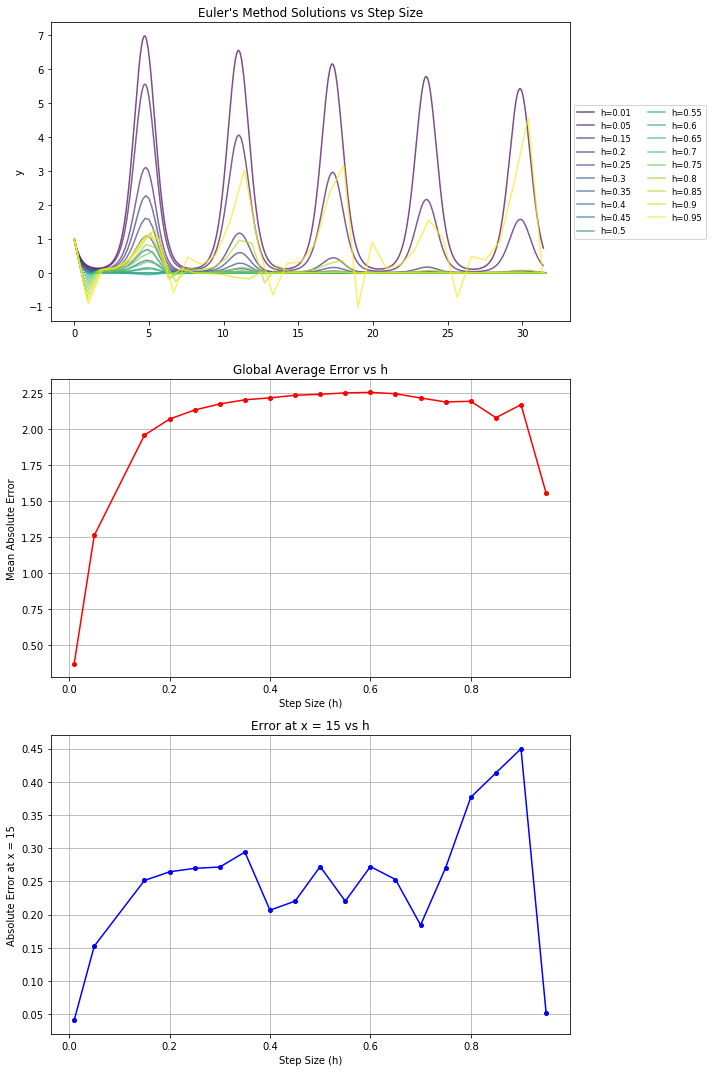

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Setup Parameters
x_start = 0
x_end = 10 * np.pi
h_values = [0.01, 0.05] + [round(val, 2) for val in np.arange(0.15, 1.0, 0.05)]

def f(x, y):
    return -2 * y * np.cos(x)

def exact_solution(x):
    return np.exp(-2 * np.sin(x))

# Storage for analysis
results = {}
averages_y = []
avg_errors = []
errors_at_15 = []

# Computation Loop
for h in h_values:
    x_vals = np.arange(x_start, x_end + h/2, h) # ensures we reach x_end
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = 1 
    
    # Euler's Method
    for i in range(len(x_vals) - 1):
        y_vals[i+1] = y_vals[i] + h * f(x_vals[i], y_vals[i])
    
    results[h] = (x_vals, y_vals)
    averages_y.append(np.mean(y_vals))
    
    # Error Analysis (compared to Exact Solution)
    y_true = exact_solution(x_vals)
    avg_errors.append(np.mean(np.abs(y_vals - y_true)))
    
    # Find index closest to 15
    idx_15 = (np.abs(x_vals - 15)).argmin()
    errors_at_15.append(np.abs(y_vals[idx_15] - exact_solution(x_vals[idx_15])))

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Euler Solutions
colors = plt.cm.viridis(np.linspace(0, 1, len(h_values)))
for i, h in enumerate(h_values):
    x, y = results[h]
    ax1.plot(x, y, color=colors[i], label=f'h={h}', alpha=0.7)
ax1.set_title("Euler's Method Solutions vs Step Size")
ax1.set_ylabel("y")
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', ncol=2)

# Plot 2: Average Error
ax2.plot(h_values, avg_errors, 'ro-', markersize=4)
ax2.set_title("Global Average Error vs h")
ax2.set_xlabel("Step Size (h)")
ax2.set_ylabel("Mean Absolute Error")
ax2.grid(True)

# Plot 3: Error at x = 15
ax3.plot(h_values, errors_at_15, 'bo-', markersize=4)
ax3.set_title("Error at x = 15 vs h")
ax3.set_xlabel("Step Size (h)")
ax3.set_ylabel("Absolute Error at x = 15")
ax3.grid(True)

plt.tight_layout()
plt.show()

Larger h values create a jagged approximation because linear steps fail to follow the curve of -2ycos(x), increasing truncation error. Stability requires |1 + hlambda| <= 1, and since our worst case lambda is -2 when cos(x)=1, we must have h <= 1.0. The error spikes as h approaches this limit, confirming the boundary where the numerical solution begins to destabilize.